# SVD-Based Movie Search Engine

This notebook implements **Latent Semantic Analysis (LSA)** for semantic movie retrieval using the Wikipedia Movie Plots dataset.

### Pipeline
1. Fetch and normalize data (one-time Kaggle download cached to `data/`)
2. Build text corpus: `title + genre + plot description` per movie
3. TF-IDF vectorization — term importance matrix
4. Truncated SVD — compress to latent semantic space
5. Cosine similarity — rank movies against a query

All reusable logic lives in `search_pipeline.py`; this notebook demonstrates and explains each step.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", message=".*IProgress.*")

from search_pipeline import (
    ensure_dataset, load_dataset,
    build_corpus, build_model, make_artifacts,
    search_movies, explain_results,
    DATA_FILE, ARTIFACT_PATH,
)

sns.set_theme(style="whitegrid")
print("Imports OK")

Imports OK


## 1) Load Dataset

`ensure_dataset()` checks whether the CSV already exists in `data/`.  
If not, it downloads from Kaggle via `kagglehub` and caches it there — **one time only**.

`load_dataset()` reads the CSV and normalises it into a fixed schema:

| Column | Source column | Notes |
|--------|--------------|-------|
| `title` | `Title` | Movie title |
| `genre` | `Genre` | Parsed into a list |
| `description` | `Plot` | Wikipedia plot text |
| `year` | `Release Year` | 4-digit int extracted from string |

In [2]:
# One-time fetch; instant on subsequent runs
csv_path = ensure_dataset()
print("Dataset file:", csv_path)

df, mapping = load_dataset()
print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Source: {mapping['source_label']}")
print(f"MD5 fingerprint: {mapping['data_fingerprint'][:16]}...")

Dataset file: data/jrobischon_wikipedia-movie-plots.csv

Shape: (34886, 5)
Columns: ['id', 'title', 'genre', 'description', 'year']
Source: local: data/jrobischon_wikipedia-movie-plots.csv
MD5 fingerprint: 7220fffcbaef32e7...


In [3]:
print("Detected column mapping:")
for k, v in mapping["mapped_columns"].items():
    print(f"  {k:12s} <- {v}")

print(f"\nFirst 5 rows:")
df.head()

Detected column mapping:
  id           <- None
  title        <- Title
  genre        <- Genre
  description  <- Plot
  year         <- Release Year

First 5 rows:


,id,title,genre,description,year
0,1,Kansas Saloon Smashers,[unknown],"A bartender is working at a saloon, serving dr...",1901
1,2,Love by the Light of the Moon,[unknown],"The moon, painted with a smiling face hangs ov...",1901
2,3,The Martyred Presidents,[unknown],"The film, just over a minute long, is composed...",1901
3,4,"Terrible Teddy, the Grizzly King",[unknown],Lasting just 61 seconds and consisting of two ...,1901
4,5,Jack and the Beanstalk,[unknown],The earliest known adaptation of the classic f...,1902


## 2) Exploratory Visualizations

Understanding the distribution of years and genres reveals the breadth of the corpus.  
A wide temporal and genre spread is important for LSA to learn meaningful latent dimensions.

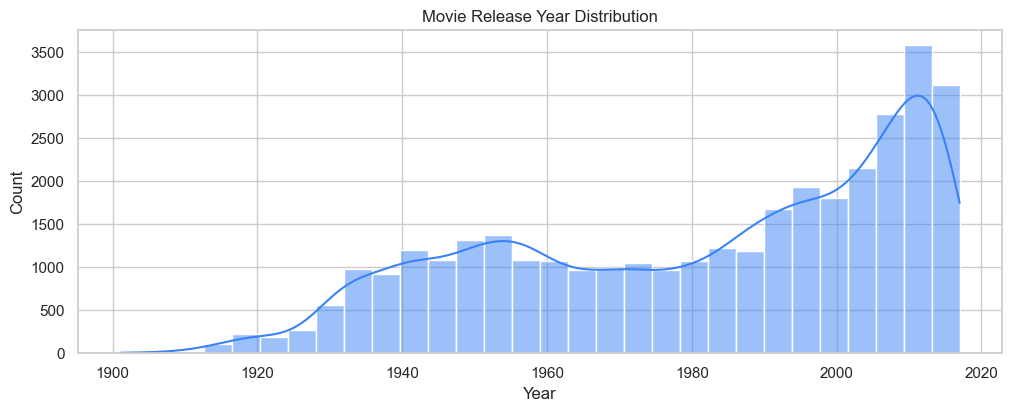

Year range: 1901 – 2017


In [4]:
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
sns.histplot(df["year"].dropna(), bins=30, kde=True, ax=ax, color="#3B82F6")
ax.set_title("Movie Release Year Distribution")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.show()
print(f"Year range: {int(df['year'].min())} – {int(df['year'].max())}")

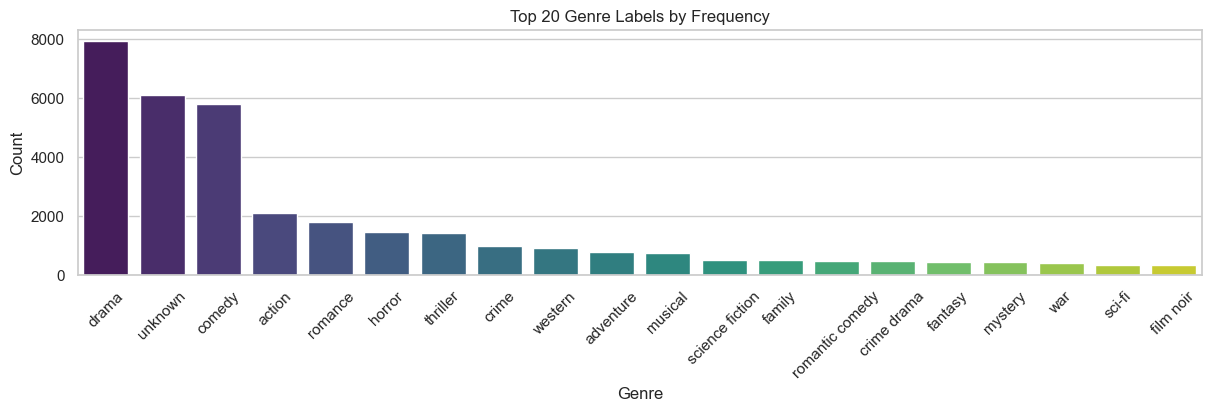

In [5]:
# Genre frequency (multi-label: each movie may have multiple genres)
genre_counts = df["genre"].explode().value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
sns.barplot(x=genre_counts.index, y=genre_counts.values,
            hue=genre_counts.index, palette="viridis", legend=False, ax=ax)
ax.set_title("Top 20 Genre Labels by Frequency")
ax.set_xlabel("Genre")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=45)
plt.show()

## 3) Build Corpus

Each movie is represented as a single text document:

```
"<title> <genre tokens> <plot description>"
```

Lowercased and concatenated, this gives TF-IDF the most informative signals.  
With 34 k+ Wikipedia plots, documents are long — ideal for LSA to find co-occurring words across many documents.

In [6]:
corpus = build_corpus(df)
print(f"Corpus size: {len(corpus):,} documents")
print(f"\nSample document (first 400 chars):")
print(corpus[0][:400])

Corpus size: 34,886 documents

Sample document (first 400 chars):
kansas saloon smashers unknown a bartender is working at a saloon, serving drinks to customers. after he fills a stereotypically irish man's bucket with beer, carrie nation and her followers burst inside. they assault the irish man, pulling his hat over his eyes and then dumping the beer over his head. the group then begin wrecking the bar, smashing the fixtures, mirrors, and breaking the cash reg


## 4) TF-IDF Vectorization

**TF-IDF** (Term Frequency–Inverse Document Frequency) converts each document into a sparse vector where each dimension is a vocabulary term:

$$\\text{TF-IDF}(t, d) = \\text{TF}(t, d) \\times \\log\\frac{N}{\\text{DF}(t)}$$

- $\\text{TF}(t,d)$ — how often term $t$ appears in document $d$
- $N$ — total number of documents
- $\\text{DF}(t)$ — number of documents containing $t$

Common words like *"the"* appear in nearly every document so their IDF weight approaches 0.  
`stop_words="english"` removes them before building the vocabulary.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")
X_tfidf = tfidf.fit_transform(corpus)

n_docs, n_terms = X_tfidf.shape
sparsity = round((1 - X_tfidf.nnz / (n_docs * n_terms)) * 100, 2)
print(f"TF-IDF matrix shape : {n_docs:,} movies × {n_terms:,} terms")
print(f"Non-zero entries    : {X_tfidf.nnz:,}")
print(f"Sparsity            : {sparsity}%")

TF-IDF matrix shape : 34,886 movies × 139,898 terms
Non-zero entries    : 4,779,587
Sparsity            : 99.9%


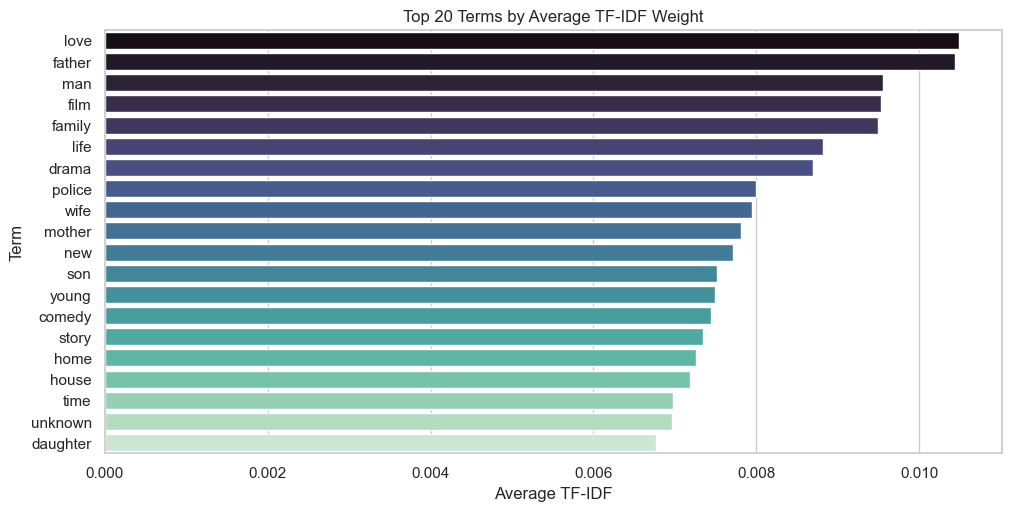

In [8]:
feature_names = np.array(tfidf.get_feature_names_out())
avg_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
top_idx = np.argsort(avg_tfidf)[-20:][::-1]

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
sns.barplot(x=avg_tfidf[top_idx], y=feature_names[top_idx],
            hue=feature_names[top_idx], palette="mako", legend=False, ax=ax)
ax.set_title("Top 20 Terms by Average TF-IDF Weight")
ax.set_xlabel("Average TF-IDF")
ax.set_ylabel("Term")
plt.show()

## 5) SVD / LSA Projection

**Latent Semantic Analysis (LSA)** applies Truncated SVD to factorize the TF-IDF matrix:

$$A \\approx U \\Sigma V^T$$

| Matrix | Shape | Meaning |
|--------|-------|---------|
| $A$ | $n_{\\text{docs}} \\times n_{\\text{terms}}$ | TF-IDF matrix |
| $U$ | $n_{\\text{docs}} \\times k$ | Document–topic weights |
| $\\Sigma$ | $k \\times k$ | Singular values (topic strength) |
| $V^T$ | $k \\times n_{\\text{terms}}$ | Topic–term weights |

Each row of $U\\Sigma$ is a movie’s **latent semantic vector** — movies about similar topics cluster together even if they use different words.  
After SVD, vectors are L2-normalised so cosine similarity reduces to a dot product.

In [9]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

N_COMPONENTS = 100
max_k = min(X_tfidf.shape[0] - 1, X_tfidf.shape[1] - 1)
n_components = min(N_COMPONENTS, max_k)

svd = TruncatedSVD(n_components=n_components, random_state=42)
normalizer = Normalizer(copy=False)
lsa = make_pipeline(svd, normalizer)

X_lsa = lsa.fit_transform(X_tfidf)
print(f"LSA matrix shape: {X_lsa.shape}  ({n_components} latent dimensions)")

LSA matrix shape: (34886, 100)  (100 latent dimensions)


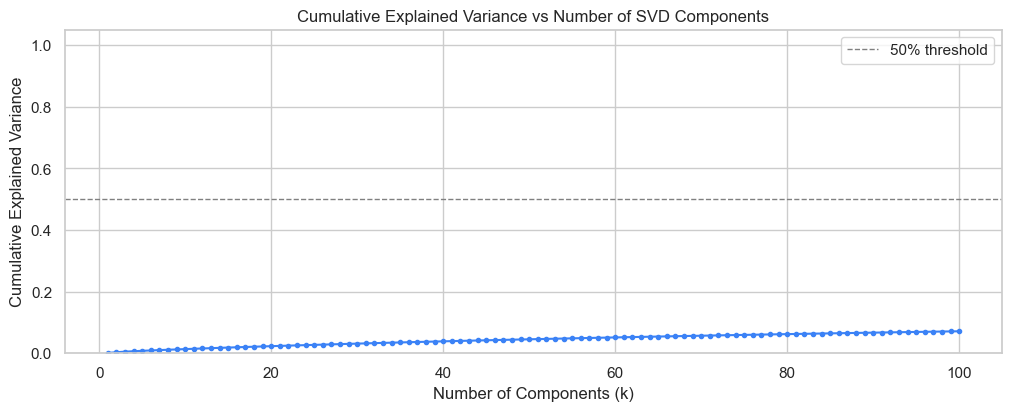

Variance captured with 100 components: 0.0711


In [10]:
explained = svd.explained_variance_ratio_
cum_explained = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.plot(range(1, len(cum_explained) + 1), cum_explained,
        marker="o", markersize=3, color="#3B82F6")
ax.axhline(0.5, ls="--", color="gray", lw=1, label="50% threshold")
ax.set_title("Cumulative Explained Variance vs Number of SVD Components")
ax.set_xlabel("Number of Components (k)")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()
print(f"Variance captured with {n_components} components: {cum_explained[-1]:.4f}")

/Users/horkimhouy/Documents/projects/python/svd_search_engine/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


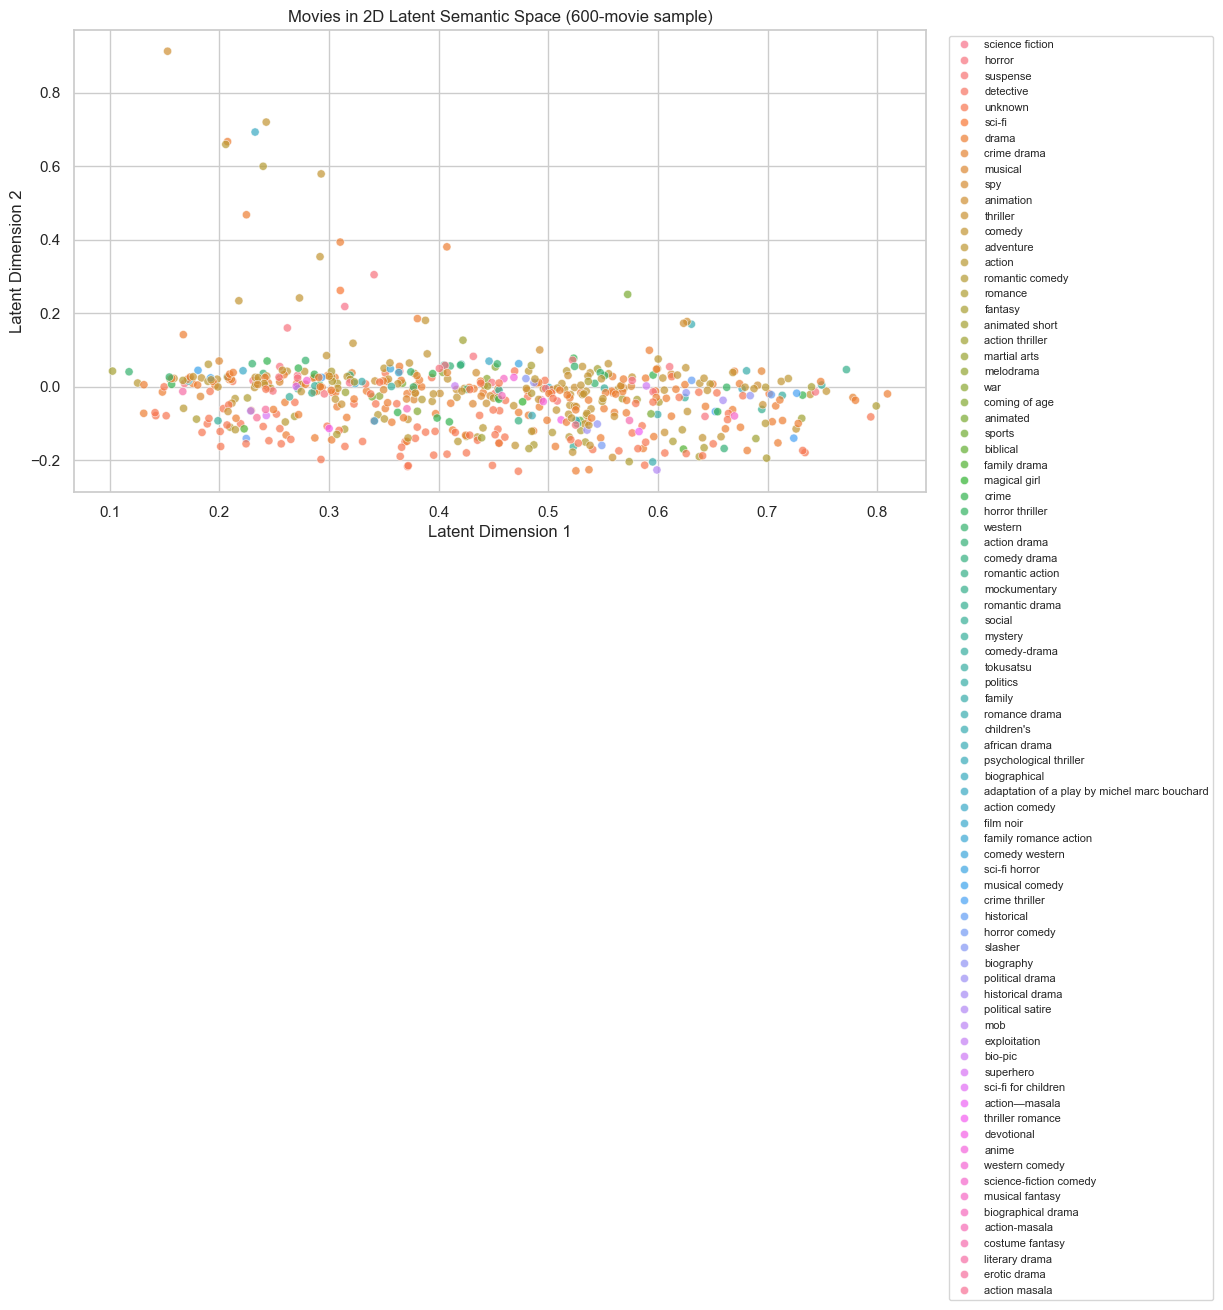

In [11]:
plot_df = pd.DataFrame({
    "dim1": X_lsa[:, 0],
    "dim2": X_lsa[:, 1],
    "genre": df["genre"].apply(lambda g: g[0] if isinstance(g, list) and g else "Unknown"),
})
sample = plot_df.sample(min(600, len(plot_df)), random_state=42)

fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
sns.scatterplot(data=sample, x="dim1", y="dim2", hue="genre",
               alpha=0.7, s=35, ax=ax)
ax.set_title("Movies in 2D Latent Semantic Space (600-movie sample)")
ax.set_xlabel("Latent Dimension 1")
ax.set_ylabel("Latent Dimension 2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.show()

## 6) Cosine Similarity Search

To retrieve movies for a query $q$:

1. Transform $q$ into TF-IDF space: $\\vec{q}_{\\text{tfidf}}$
2. Project into LSA space: $\\vec{q}_{\\text{lsa}} = \\vec{q}_{\\text{tfidf}} \\cdot V$
3. Compute cosine similarity against every movie vector $\\vec{m}_i$:

$$\\text{sim}(q, m_i) = \\frac{\\vec{q}_{\\text{lsa}} \\cdot \\vec{m}_i}{\\|\\vec{q}_{\\text{lsa}}\\| \\, \\|\\vec{m}_i\\|}$$

Because vectors are L2-normalised after the LSA step this simplifies to a dot product.  
Results are ranked by descending similarity and the top-$k$ are returned.

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

def search(query, tfidf_model, lsa_model, X_lsa_matrix, movies_df, top_k=10):
    query_vec = tfidf_model.transform([query])
    query_lsa = lsa_model.transform(query_vec)
    scores = cosine_similarity(query_lsa, X_lsa_matrix)[0]
    top_idx = np.argsort(scores)[::-1][:top_k]
    rows = []
    for i in top_idx:
        rows.append({
            "title": movies_df.iloc[i]["title"],
            "genre": ", ".join(movies_df.iloc[i]["genre"]),
            "year": movies_df.iloc[i]["year"],
            "similarity": float(scores[i]),
        })
    return pd.DataFrame(rows)

query = "Whale"
results = search(query, tfidf, lsa, X_lsa, df, top_k=10)
print(f"Query: '{query}'")
results

Query: 'Whale'


,title,genre,year,similarity
0,Sinbad the Sailor,fantasy,1947,0.840796
1,Moby Dick,adventure,1956,0.835559
2,Windjammer,adventure,1930,0.833036
3,In the Heart of the Sea,thriller,2015,0.830565
4,Captain Calamity,"adventure, romance",1936,0.823957
5,The Navigator,comedy,1924,0.815286
6,The Black Pirate,swashbuckler,1926,0.812158
7,The Icebreaker,unknown,2016,0.811004
8,The Mutiny of the Elsinore,action,1937,0.808546
9,Mutiny on the Bounty,"drama, adventure",1935,0.808125


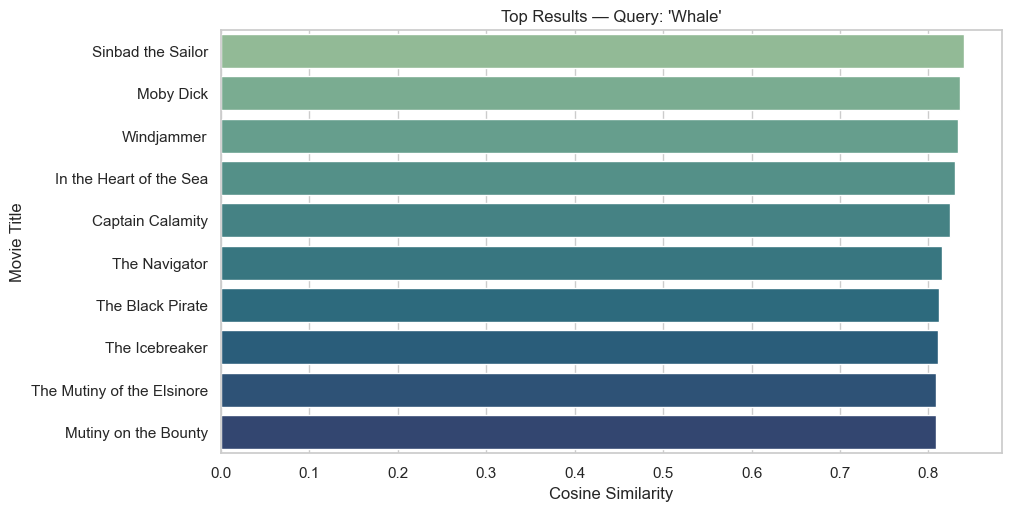

In [14]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
sns.barplot(data=results, y="title", x="similarity",
            hue="title", palette="crest", dodge=False, legend=False, ax=ax)
ax.set_title(f"Top Results — Query: '{query}'")
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Movie Title")
plt.show()

## 7) Multi-Query Comparison

Testing several queries across different semantic intents shows how LSA captures topic-level meaning — a query for *"detective mystery"* surfaces thrillers even when the exact word *"detective"* is absent from a plot.

In [15]:
queries = [
    "space mission astronaut",
    "love story romance",
    "detective mystery crime",
    "monster terror survival",
    "war battlefield soldiers",
]

for q in queries:
    top3 = search(q, tfidf, lsa, X_lsa, df, top_k=3)
    print(f"\n{'='*70}")
    print(f"Query: '{q}'")
    display(top3[["title", "genre", "year", "similarity"]])


Query: 'space mission astronaut'


,title,genre,year,similarity
0,Uchū Senkan Yamato 2199: Hoshi-Meguru Hakobune,science fiction anime,2014,0.949178
1,Gorath,sci-fi,1962,0.943449
2,X from Outer Space !The X from Outer Space,unknown,1967,0.919878



Query: 'love story romance'


,title,genre,year,similarity
0,Char Dil Char Rahen,social drama romance,1959,0.926722
1,Khichdi: The Movie,comedy,2010,0.906295
2,Kote,action,2011,0.899731



Query: 'detective mystery crime'


,title,genre,year,similarity
0,The Loudwater Mystery,crime,1921,0.975019
1,Murder at Covent Garden,crime,1932,0.949610
2,East of Piccadilly,mystery,1941,0.933167



Query: 'monster terror survival'


,title,genre,year,similarity
0,The Ghost of Frankenstein,horror,1942,0.840887
1,Kaibutsu-kun,unknown,1981,0.821700
2,Kaibutsu-kun–Demon no ken,unknown,1982,0.814766



Query: 'war battlefield soldiers'


,title,genre,year,similarity
0,13 Men and a Gun,war,1938,0.978184
1,Who Goes Next?,war,1938,0.968151
2,Hanna's War,action,1988,0.944875


## 8) Why These Results? (Term-Level Explanation)

We project the overlap between query and result back through the SVD components  
to identify which vocabulary terms most drove that particular match.

In [16]:
# Wrap all models in a PipelineArtifacts for use with explain_results
artifacts, _ = make_artifacts(df, n_components=100,
                              data_fingerprint=mapping['data_fingerprint'])

query_exp = "haunted house ghost"
# Build a result dataframe aligned with artifacts.X_lsa row indices
query_vec_exp = artifacts.tfidf.transform([query_exp])
query_lsa_exp = artifacts.lsa.transform(query_vec_exp)
from sklearn.metrics.pairwise import cosine_similarity
scores_exp = cosine_similarity(query_lsa_exp, artifacts.X_lsa)[0]
top5_idx = np.argsort(scores_exp)[::-1][:5]
result_df_exp = pd.DataFrame([
    {
        "title": df.iloc[i]["title"],
        "genre": ", ".join(df.iloc[i]["genre"]),
        "year": df.iloc[i]["year"],
        "similarity": float(scores_exp[i]),
    }
    for i in top5_idx
], index=top5_idx)

explanations = explain_results(query_exp, result_df_exp, artifacts, top_n=5)
for idx, row in result_df_exp.iterrows():
    terms = explanations.get(idx, [])
    print(f"\n{row['title']}  (sim={row['similarity']:.4f})")
    for term, score in terms:
        print(f"  {term:20s}  {score:.6f}")


A Ghost Story  (sim=0.8090)
  love                  0.034828
  helen                 0.030979
  jimmy                 0.030529
  anne                  0.027811
  radha                 0.026672

Ghost Dog: The Way of the Samurai  (sim=0.7921)
  helen                 0.036793
  anne                  0.031703
  love                  0.028751
  jake                  0.024603
  julie                 0.022378

The Secret  (sim=0.7836)
  anne                  0.028599
  julie                 0.026644
  film                  0.026589
  love                  0.024039
  mohan                 0.023708

Prema Katha Chitram  (sim=0.7815)
  anne                  0.029357
  love                  0.027686
  film                  0.026191
  helen                 0.025474
  julie                 0.024213

Ice Cream  (sim=0.7719)
  love                  0.026067
  helen                 0.024981
  film                  0.024351
  anne                  0.023968
  julie                 0.023612


## 9) Summary

| Step | Method | Output |
|------|--------|--------|
| Data | Wikipedia Movie Plots (34 k+ movies) | `df` — title, genre, description, year |
| Corpus | title + genre + plot | 34 k+ text documents |
| TF-IDF | `TfidfVectorizer(stop_words="english")` | Sparse matrix $n \\times v$ |
| LSA | `TruncatedSVD(k=100)` + L2 normalisation | Dense matrix $n \\times k$ |
| Search | Cosine similarity in latent space | Top-$k$ ranked results |

**Key insight**: LSA works well here because Wikipedia plot descriptions are long and rich —  
many movies share vocabulary around themes (e.g., *"war", "soldier", "battle"*),  
so SVD extracts those latent dimensions and groups thematically related films together.

---

The full pipeline is available as `search_pipeline.py` and served interactively via the Streamlit app (`streamlit run App.py`).